In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules'))

# General imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT


In [3]:
cell_num = 37 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]



In [4]:
# Parameters
FORCE_CLUSTER = False


### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [5]:
lfp_dir = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings', f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')


In [6]:
#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

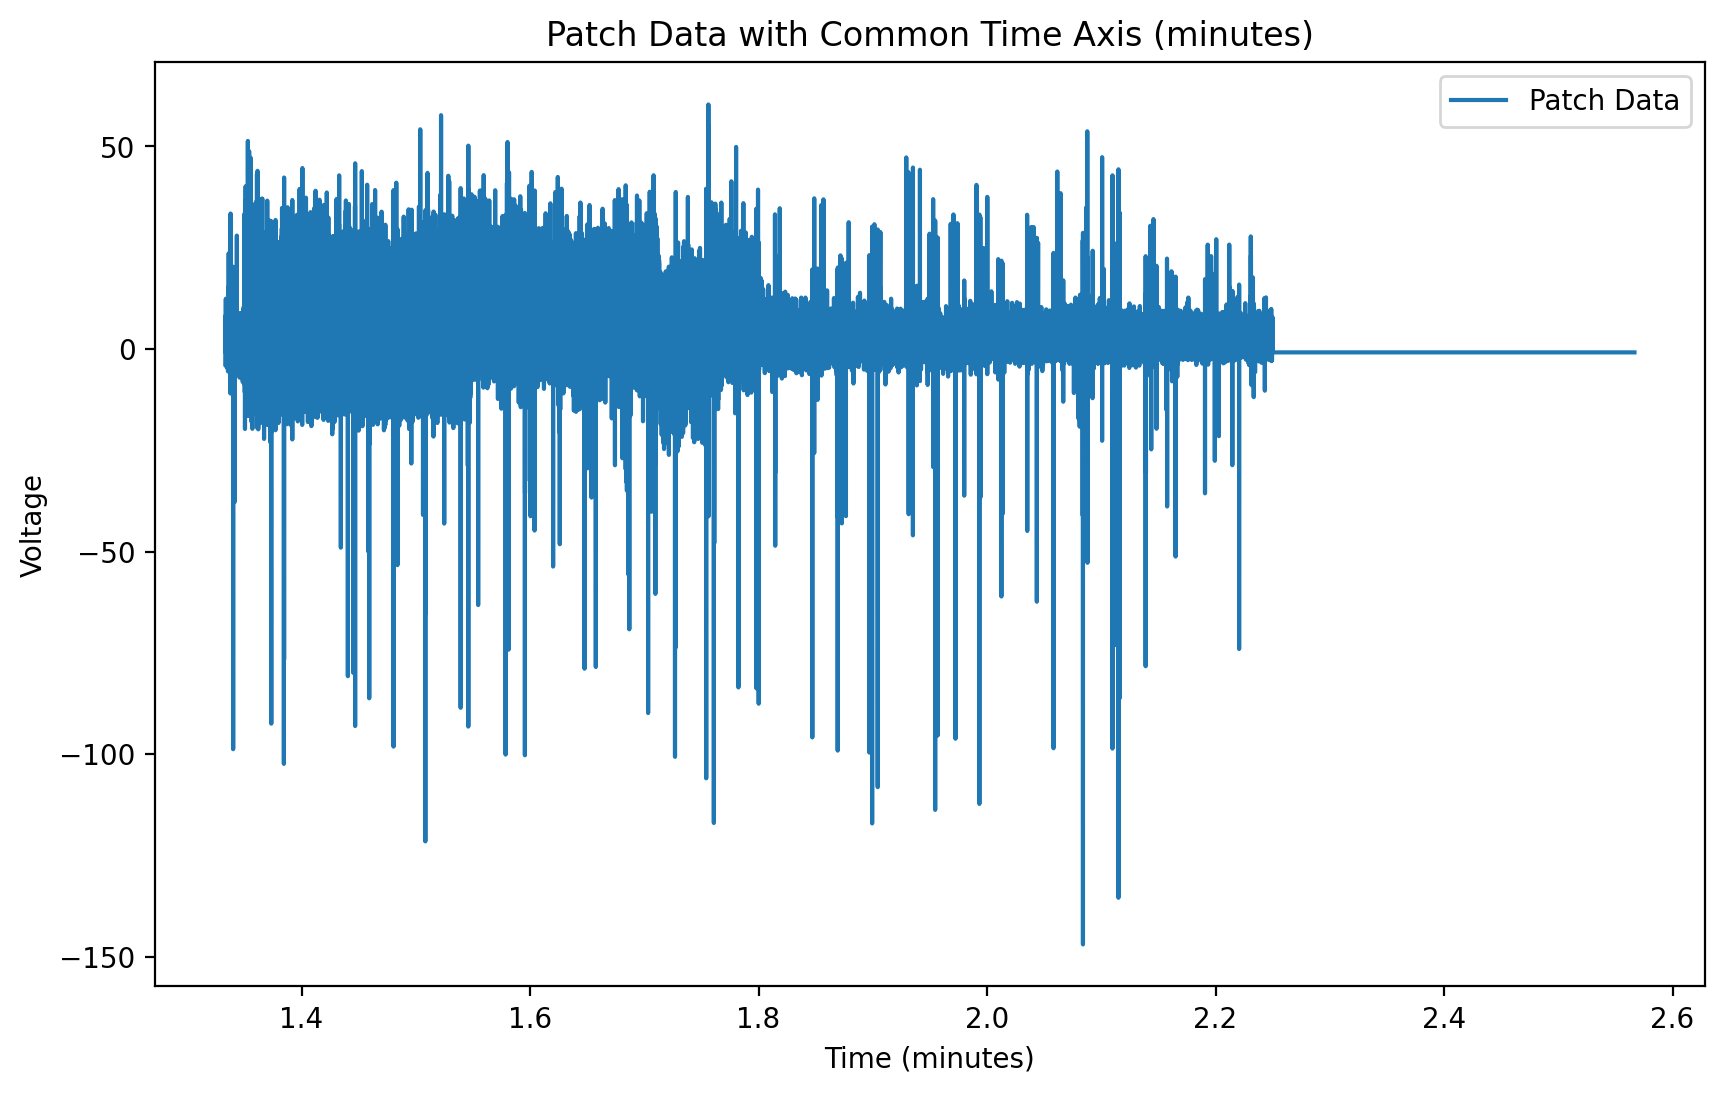

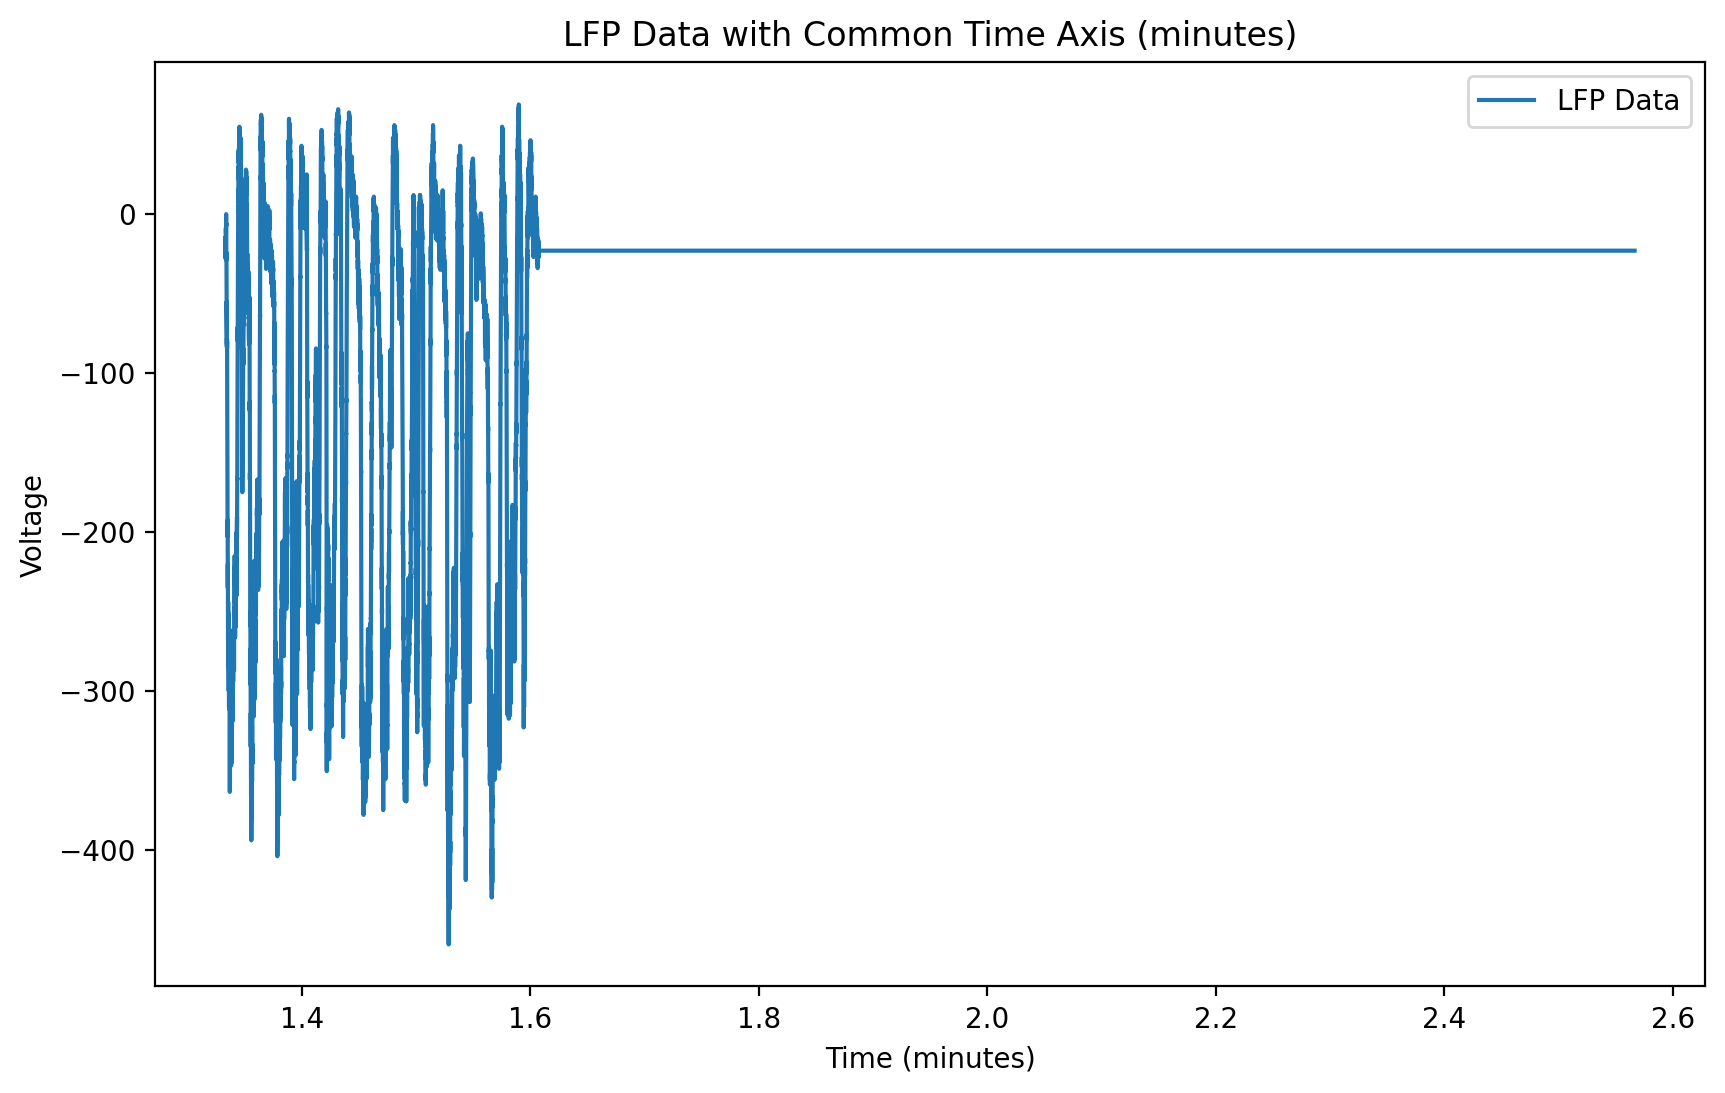

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

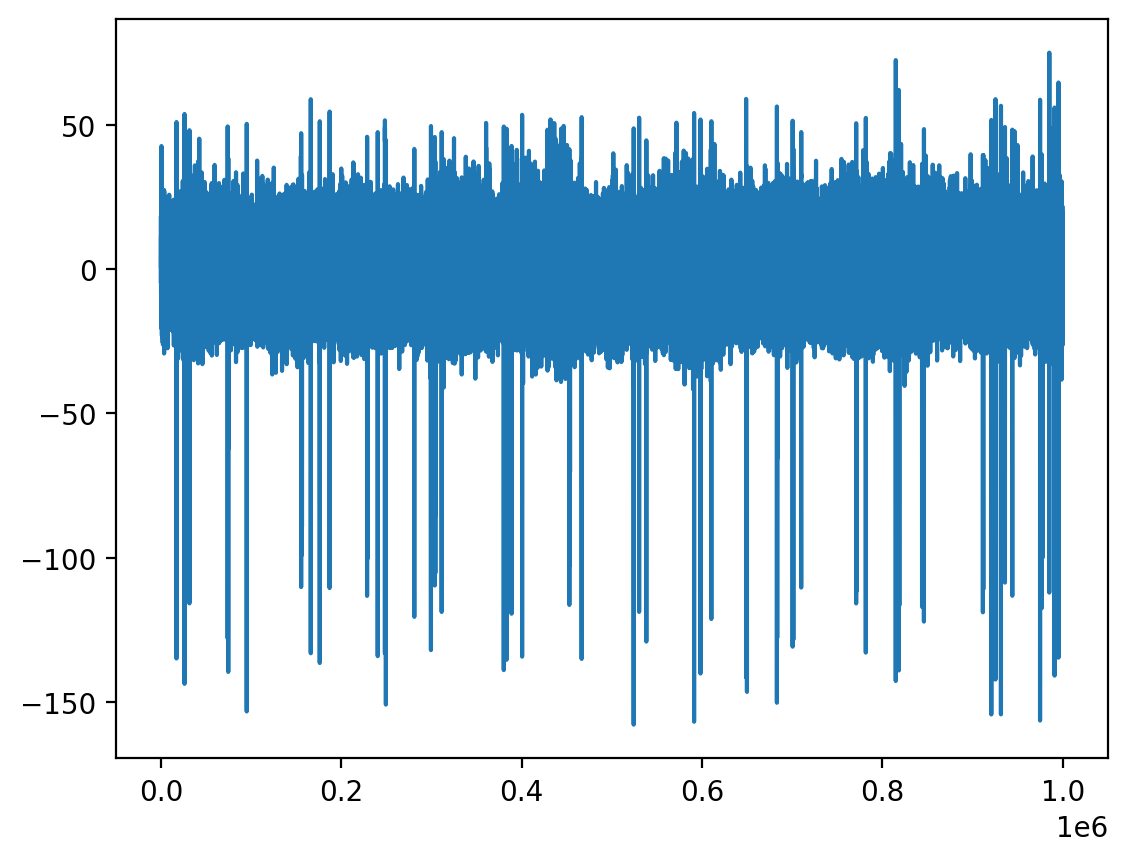

In [8]:
plt.plot(patch_filt[:1000000] )

In [9]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [10]:
#CHANGE FOR EACH CELL
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/614 [00:00<?, ?it/s]

Spike:   0%|          | 1/614 [00:03<33:13,  3.25s/it]

Spike:   1%|          | 6/614 [00:03<04:24,  2.30it/s]

Spike:   9%|▊         | 53/614 [00:03<00:20, 27.49it/s]

Spike:  13%|█▎        | 77/614 [00:03<00:12, 42.58it/s]

...

Spike:  87%|████████▋ | 536/614 [00:05<00:00, 201.28it/s]

Spike:  91%|█████████ | 557/614 [00:06<00:00, 193.34it/s]

Spike:  94%|█████████▍| 579/614 [00:06<00:00, 196.89it/s]

Spike:  98%|█████████▊| 601/614 [00:06<00:00, 192.28it/s]

Spike: 100%|██████████| 614/614 [00:06<00:00, 96.44it/s] 

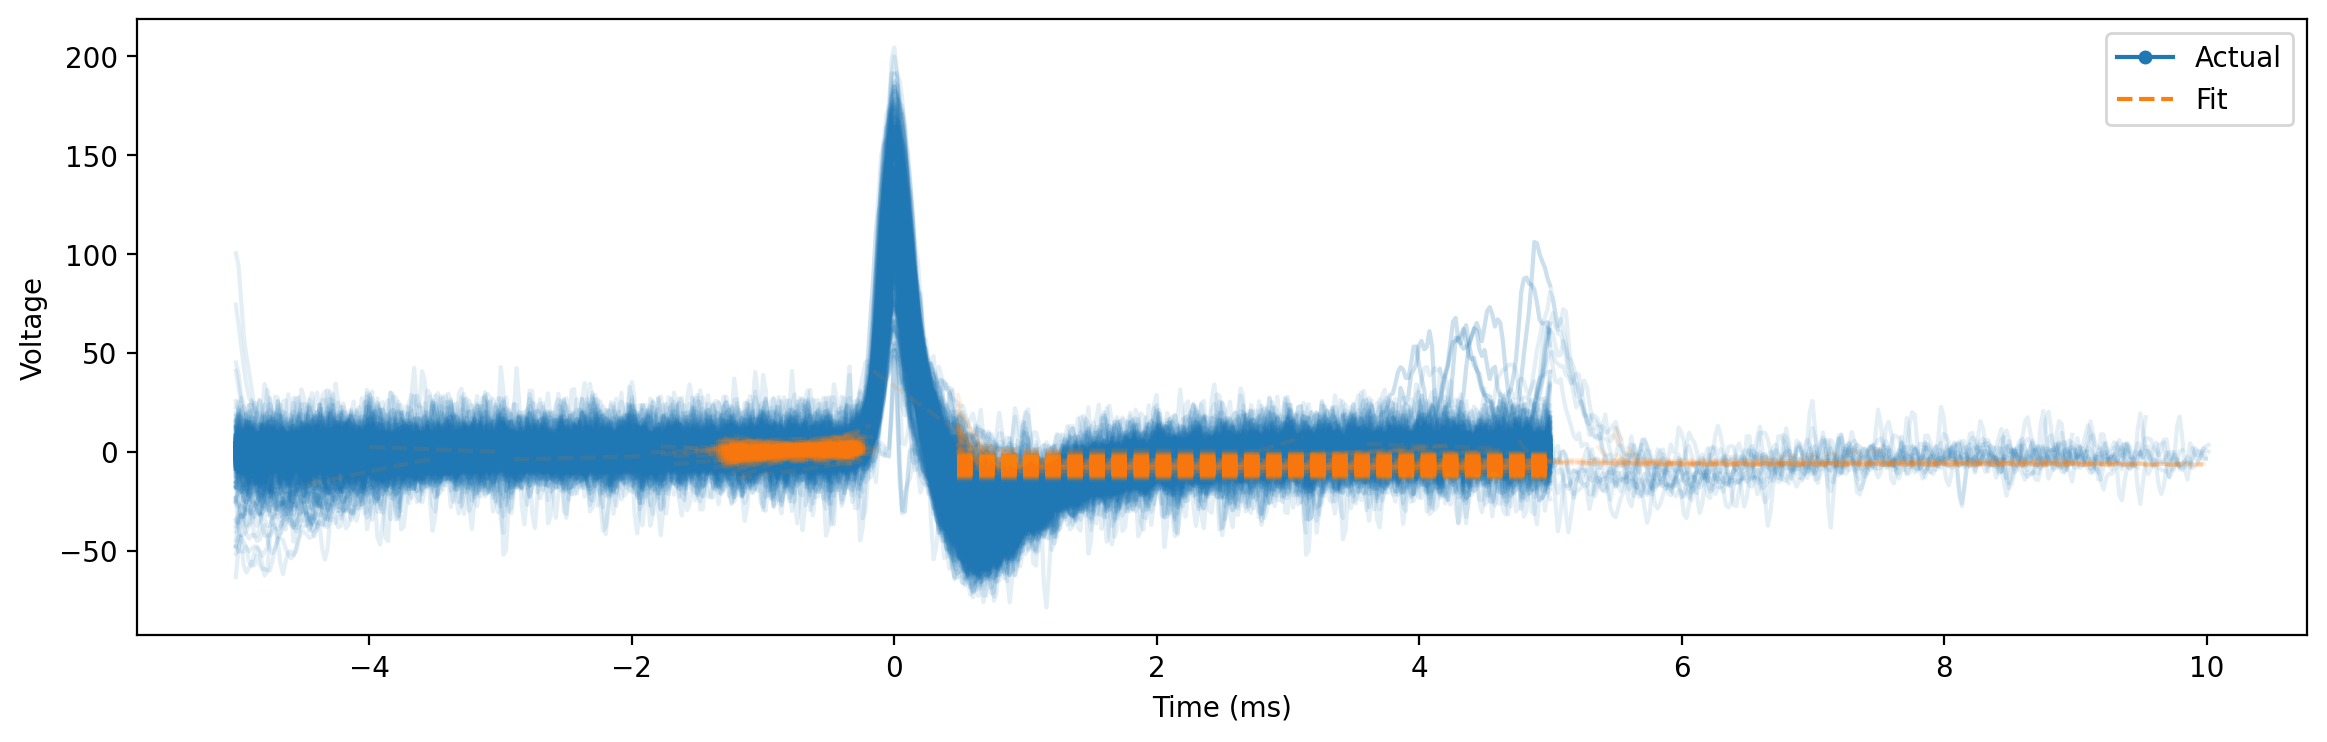

In [11]:
sp.plot()

### Filter spikes 

In [12]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [13]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [14]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.794880,0.24,-6.585427,133.804329,0.24,54.939839,2.040837e-06,-8.795310,0.738573,17250,344.835252,0
1,3.985381,0.24,5.017446,102.674385,0.24,36.927162,4.714522e-06,-8.500764,2.237889,17524,350.312635,1
2,-0.175405,0.24,5.885388,139.000088,0.22,64.450391,9.337293e-07,-9.611442,2.036900,26175,523.250013,2
3,-2.974633,0.26,-1.297301,113.448165,0.26,41.799389,2.645070e-06,-7.167559,2.927850,31621,632.118001,3
4,1.015981,0.22,1.043020,120.673345,0.26,52.747582,3.013887e-05,-7.291129,1.142807,73988,1479.053371,4
...,...,...,...,...,...,...,...,...,...,...,...,...
609,1.254851,0.16,12.554664,74.182108,0.14,46.372573,7.646122e-06,-2.359972,2.228450,6656567,133067.765863,605
610,-1.451401,0.16,7.390726,67.776497,0.18,31.395433,6.849900e-06,-3.663847,2.786998,6665032,133236.985017,606
611,0.796256,0.22,3.472212,88.312105,0.14,50.301439,7.513478e-06,-2.642895,0.954035,6695664,133849.332463,607
612,-1.789825,0.20,4.802812,77.991204,0.18,41.143383,1.742824e-05,-3.563437,2.014985,6696114,133858.328166,608


### Get spike times


In [15]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [16]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi',
       'spk_times_idx', 'spk_times_ms', 'spk_id'],
      dtype='str')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


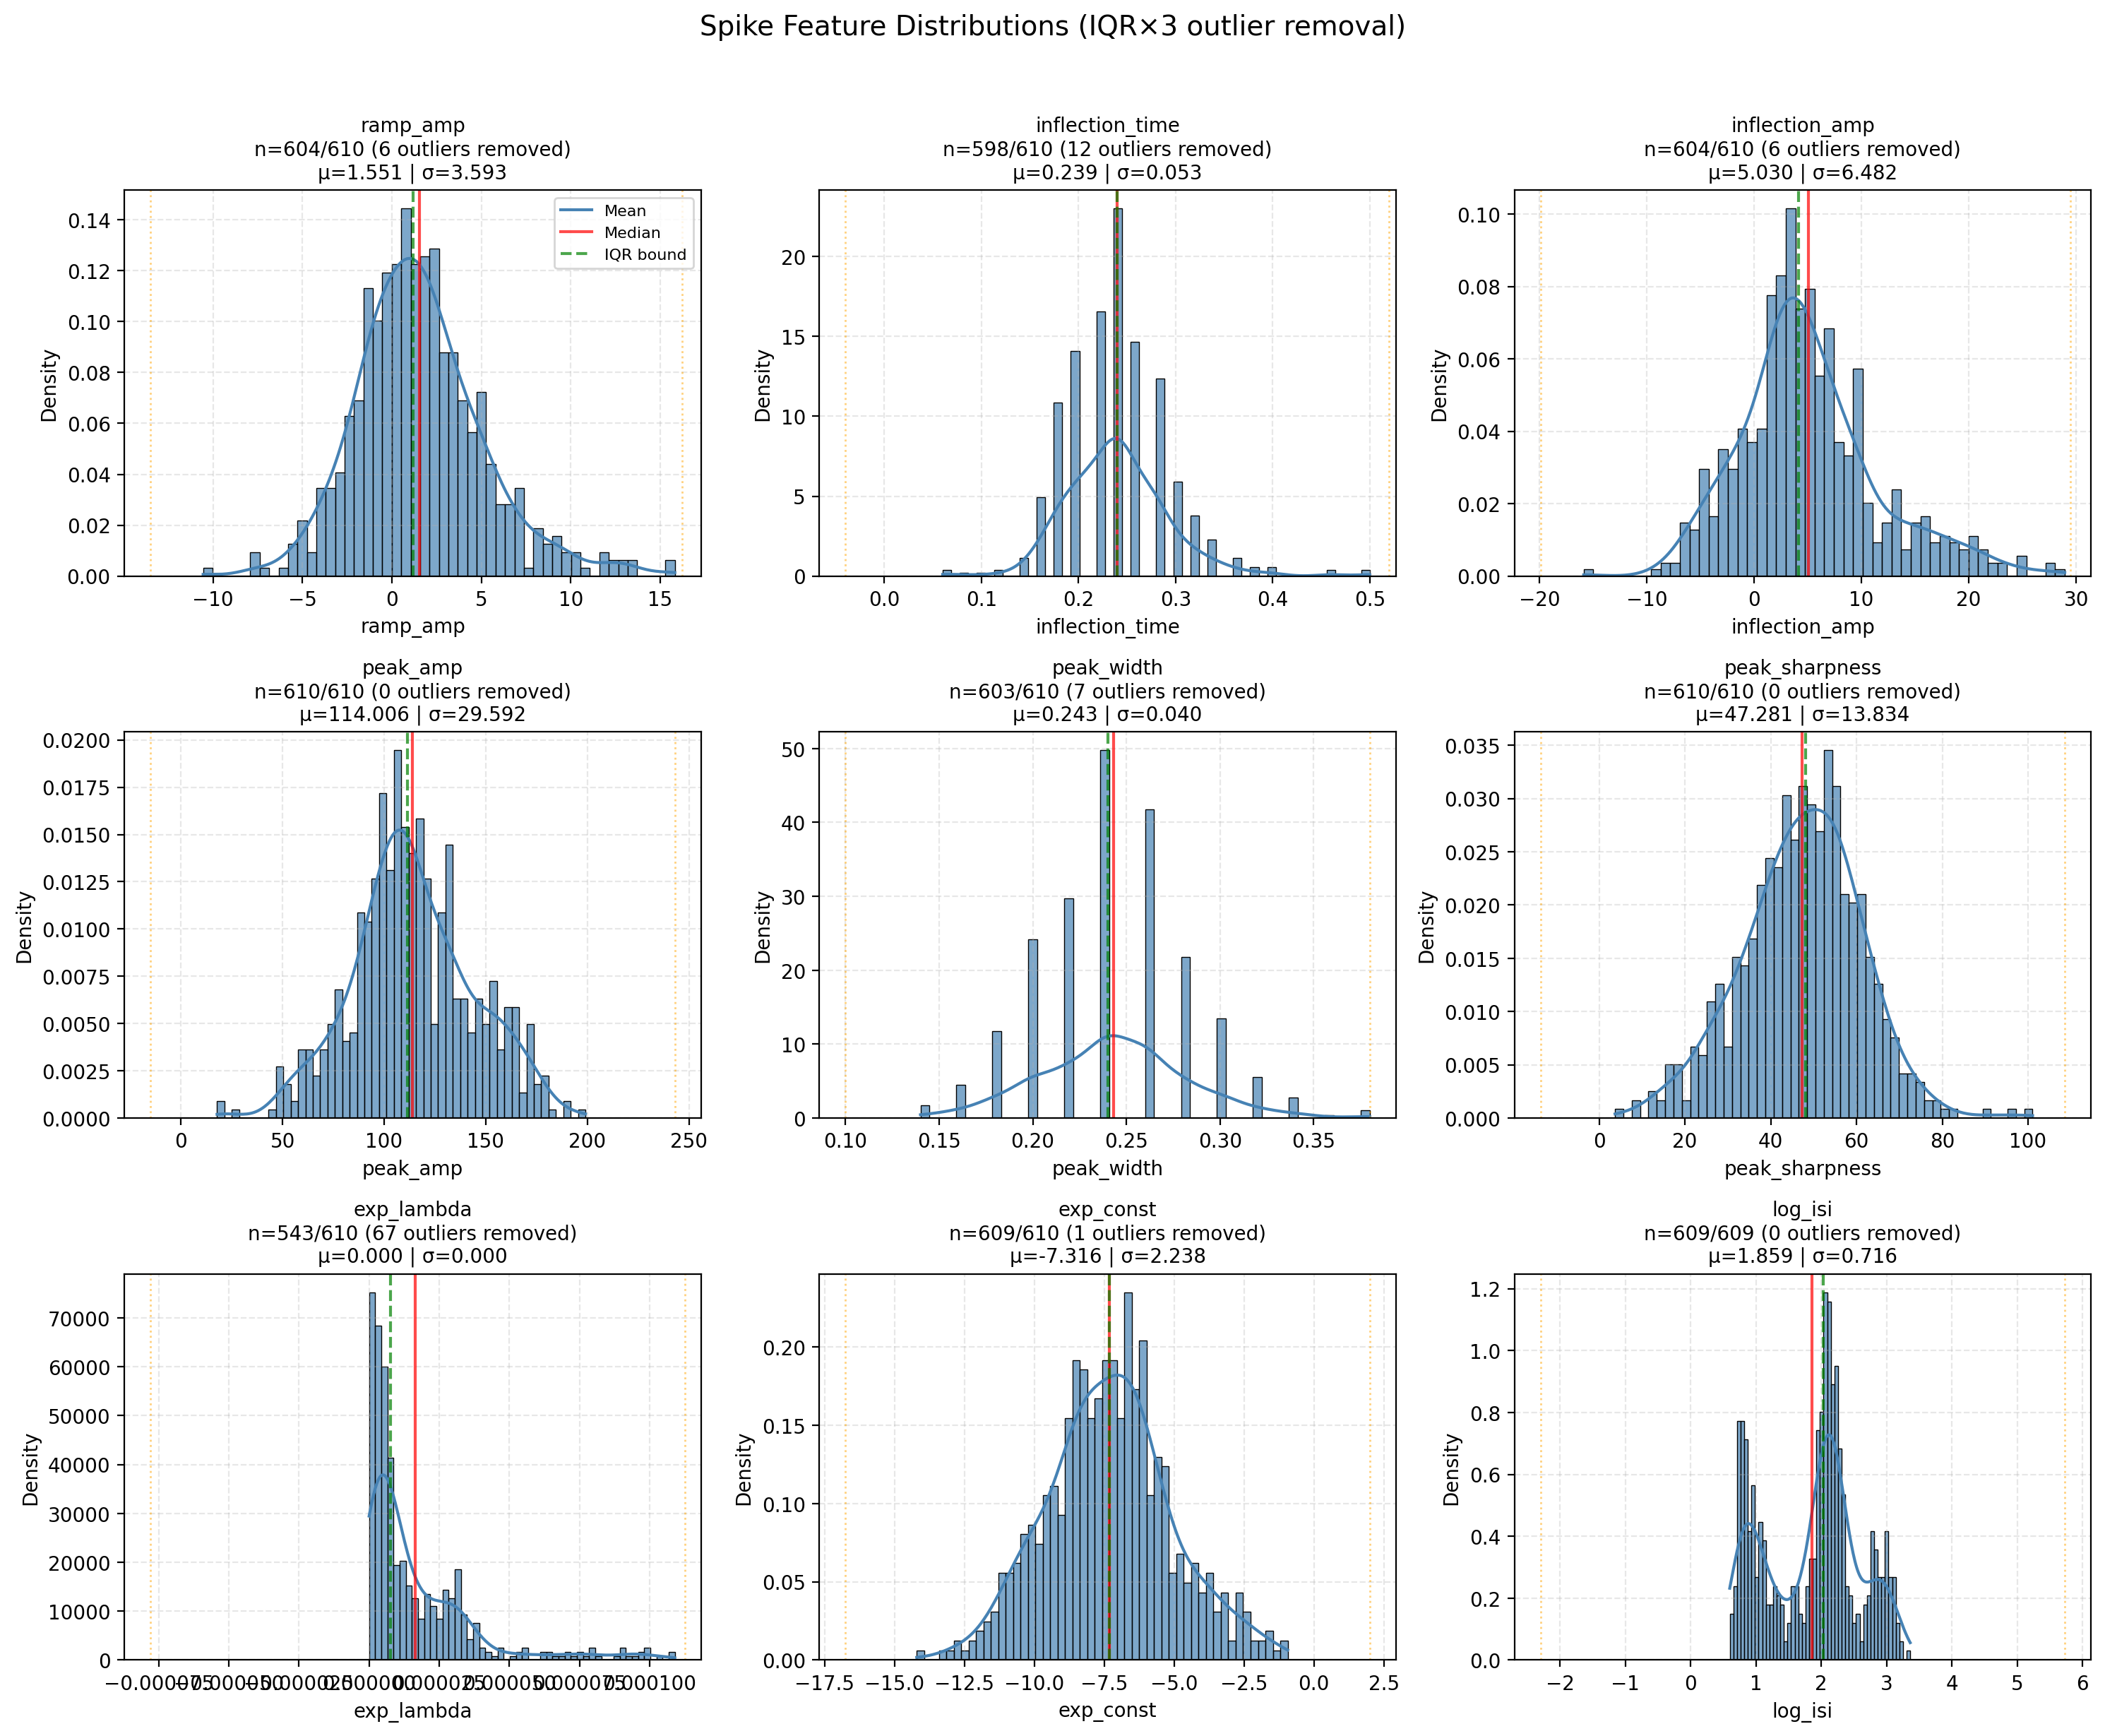


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             610        604        6          1.0        1.551      3.593     
inflection_time      610        598        12         2.0        0.239      0.053     
inflection_amp       610        604        6          1.0        5.030      6.482     
peak_amp             610        610        0          0.0        114.006    29.592    
peak_width           610        603        7          1.1        0.243      0.040     
peak_sharpness       610        610        0          0.0        47.281     13.834    
exp_lambda           610        543        67         11.0       0.000      0.000     
exp_const            610        609        1          0.2        -7.316     2.238     
log_isi              609        609        0          0.0        1.859      0.716     


In [17]:
plot_spike_feature_distributions(df_features)

In [18]:
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')

if FORCE_CLUSTER or not os.path.exists(cluster_pickle):
    # scan all numeric features and only cluster the ones that look multimodal
    df_features_clust, rep = cluster_multimodal_features(
        df_features,
        max_k=2, ignore_features = "peak_width",
        suffix="_cluster",
        plot_each=True,  # set True if you want a quick plot per clustered feature, 
        manual_thresholds={}
    )
    
    
    with open(cluster_pickle, 'wb') as f:
        pickle.dump(df_features_clust, f)
    print(f"  Saved: {os.path.basename(cluster_pickle)}")
else:
    print(f"  [cache] {os.path.basename(cluster_pickle)}")
    with open(cluster_pickle, 'rb') as f:
        df_features_clust = pickle.load(f)


  [cache] c37_cluster_df.pkl



===== CLUSTER REPORT: log_isi_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster


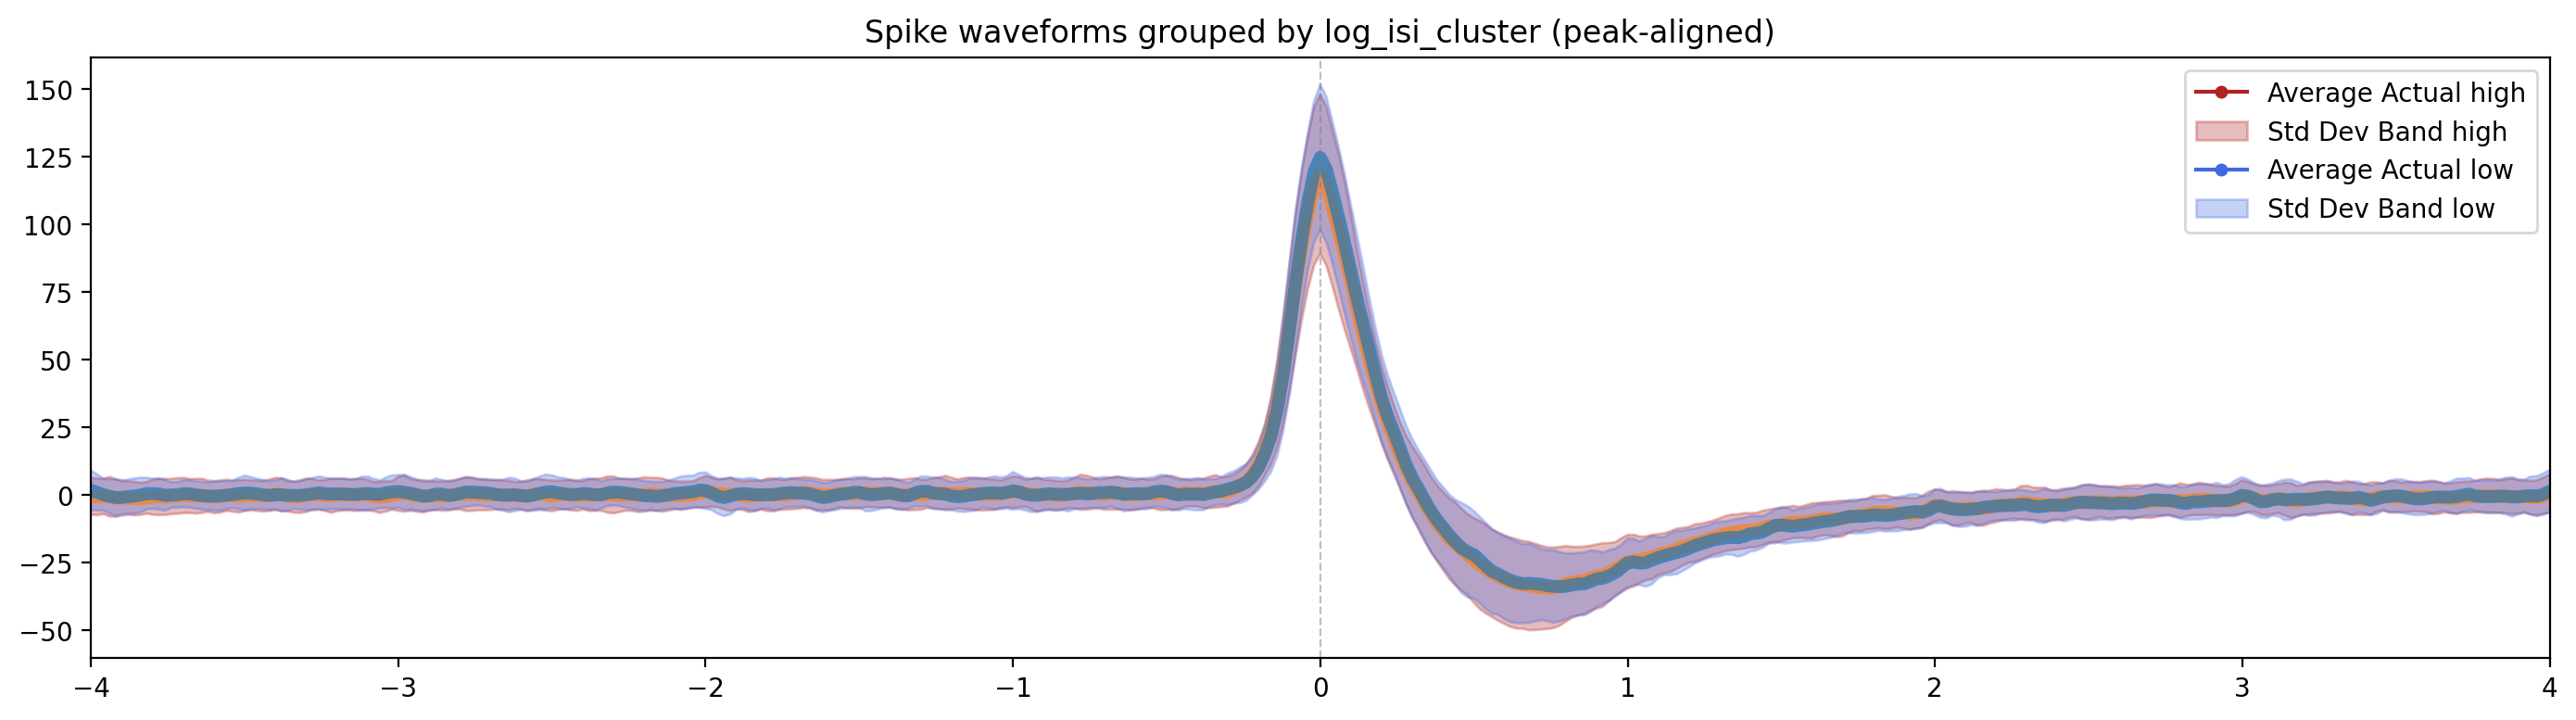


→ 1.5 Average waveforms with visual RMSE


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_analysis.py:988: RuntimeWarning: Mean of empty slice
  avg_waveforms[group]    = np.nanmean(arr, axis=0)


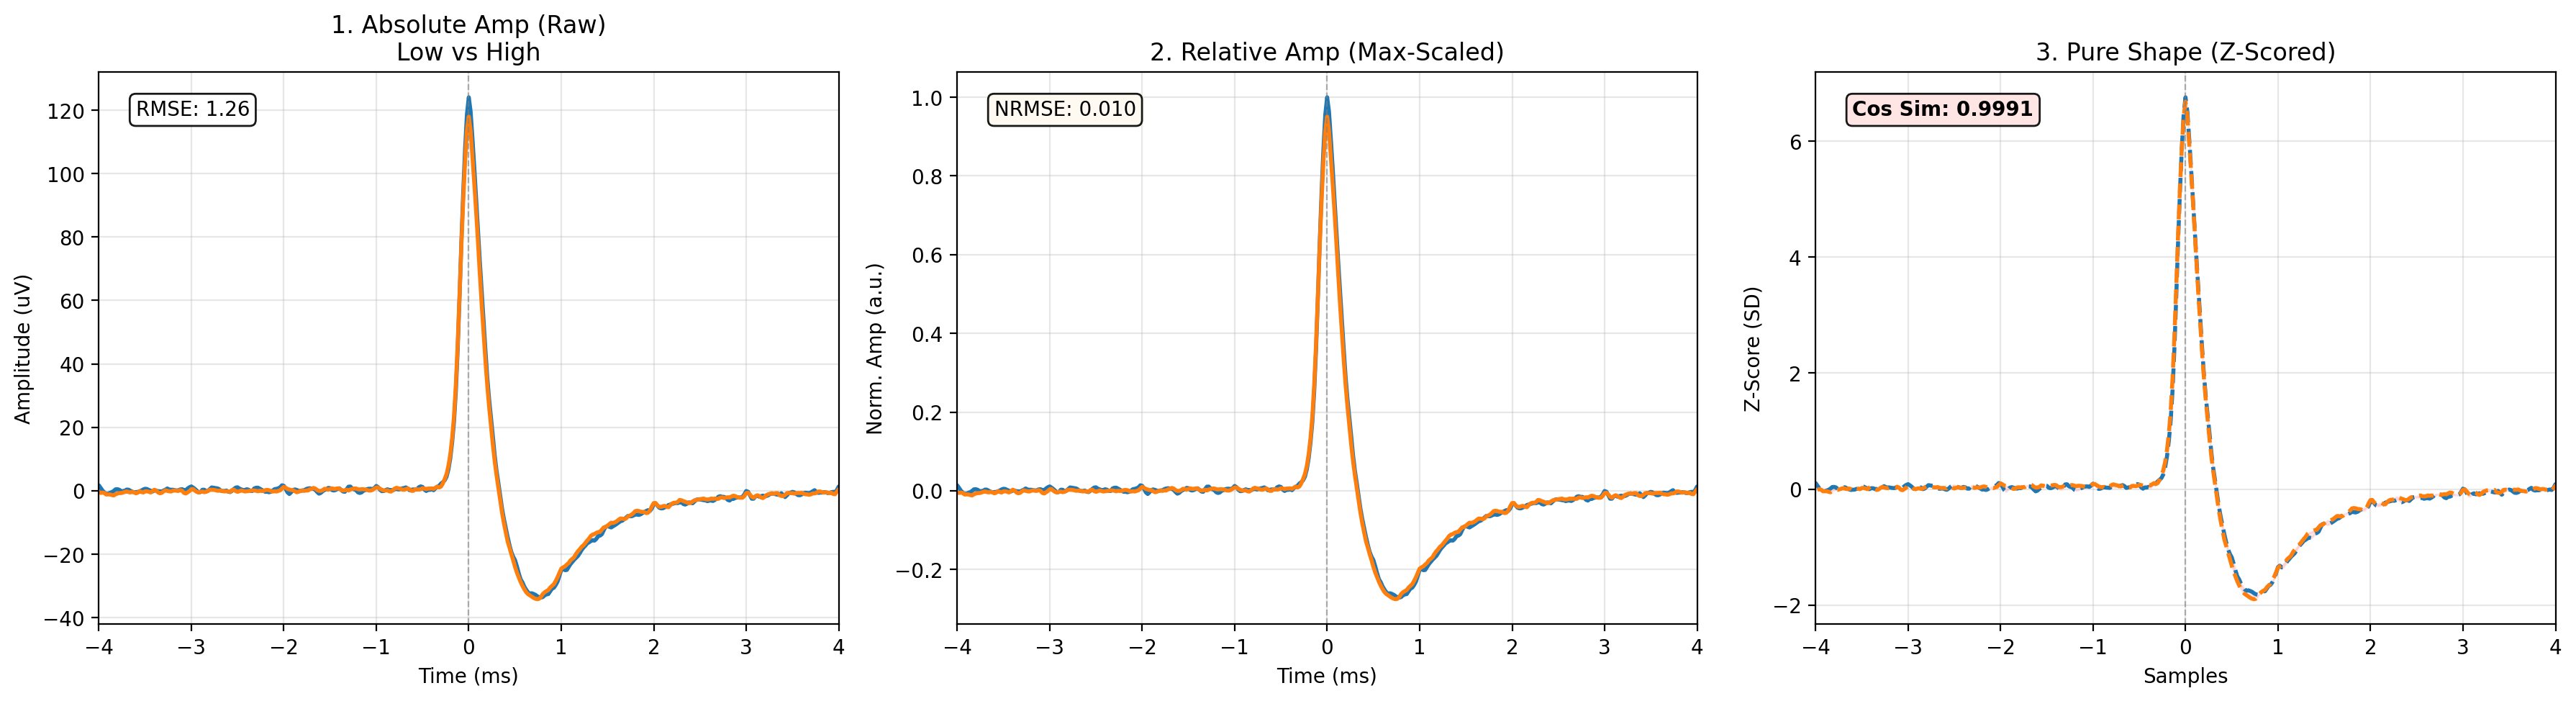


→ 2. Plotting cluster proportions over time


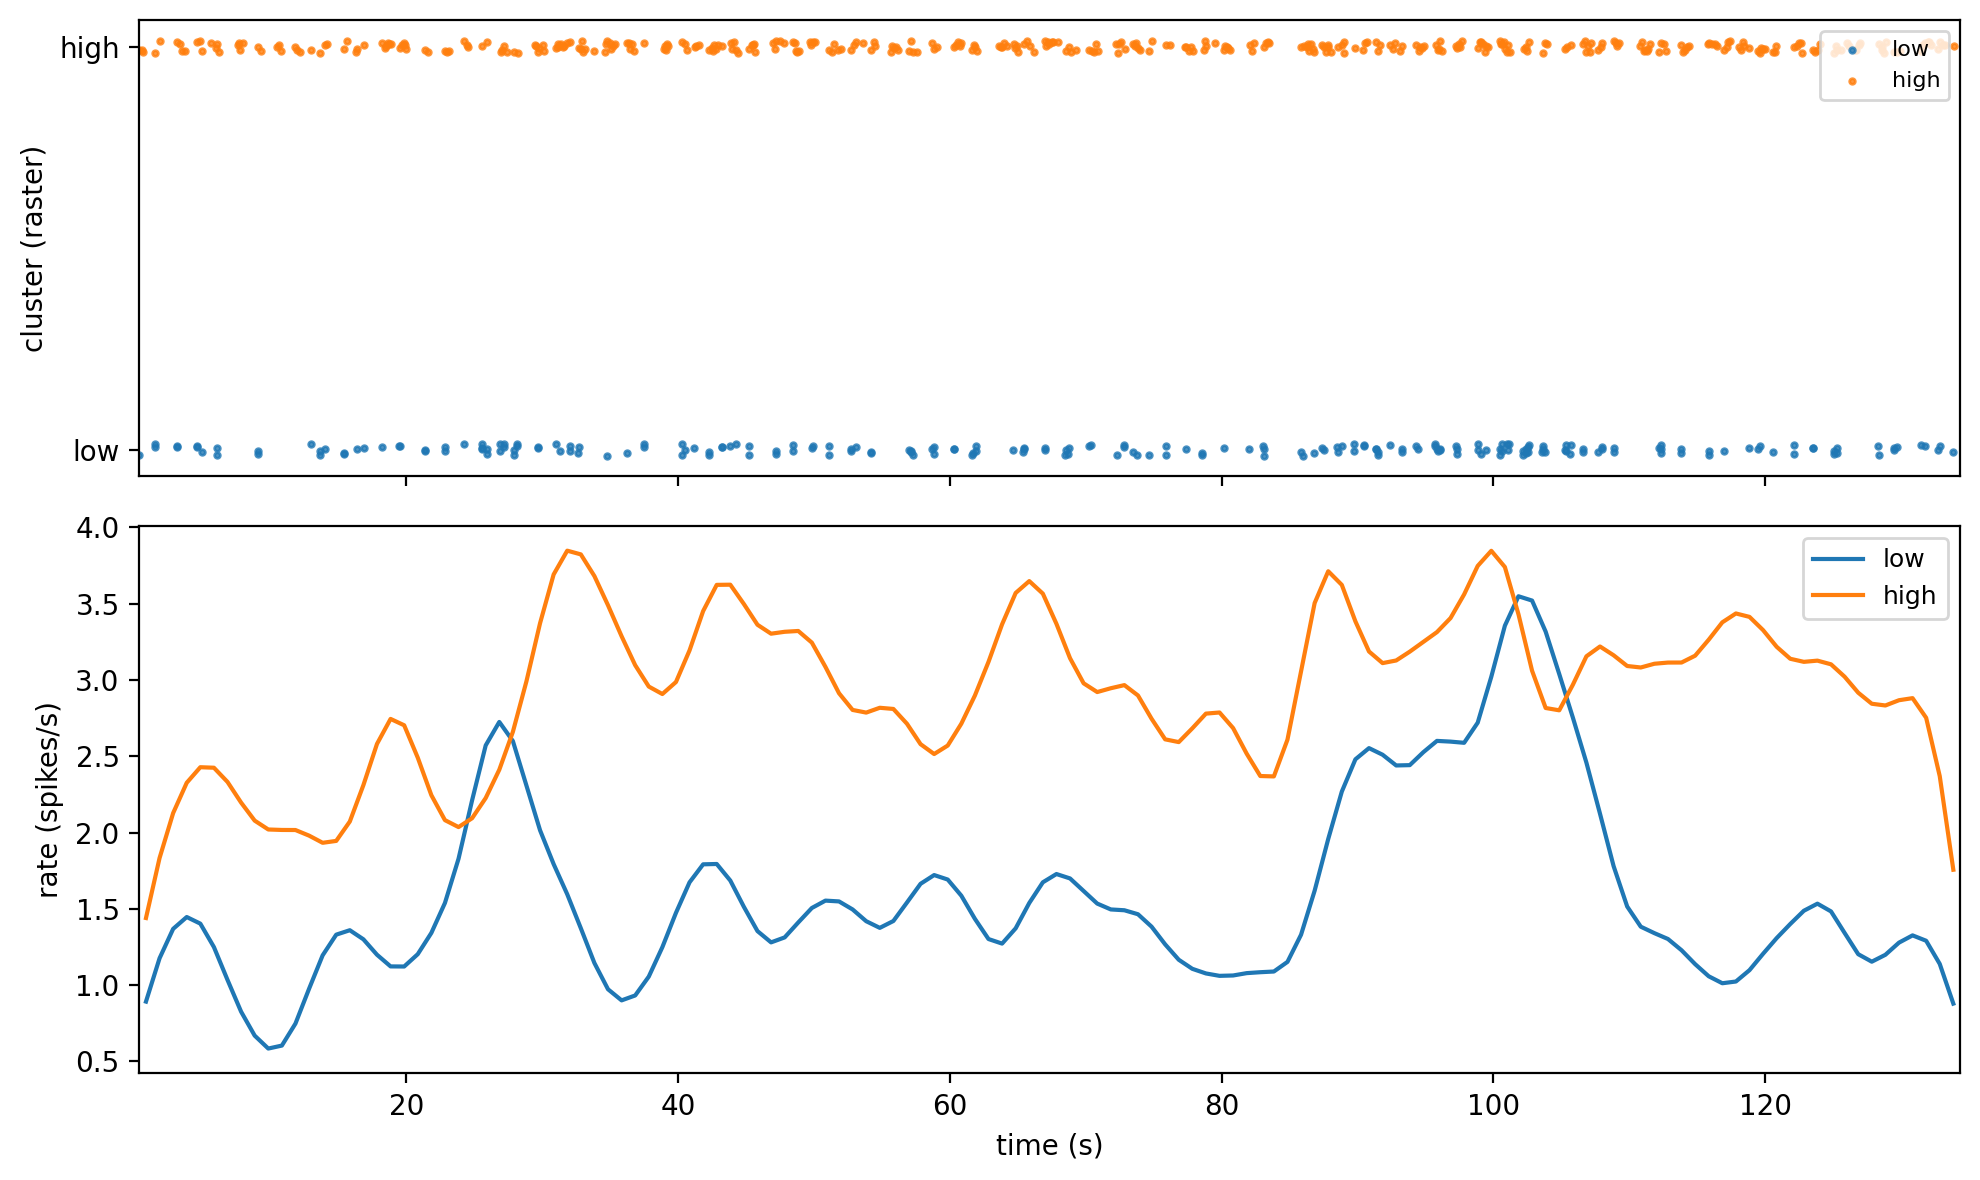


→ 3. Computing cluster transition matrix


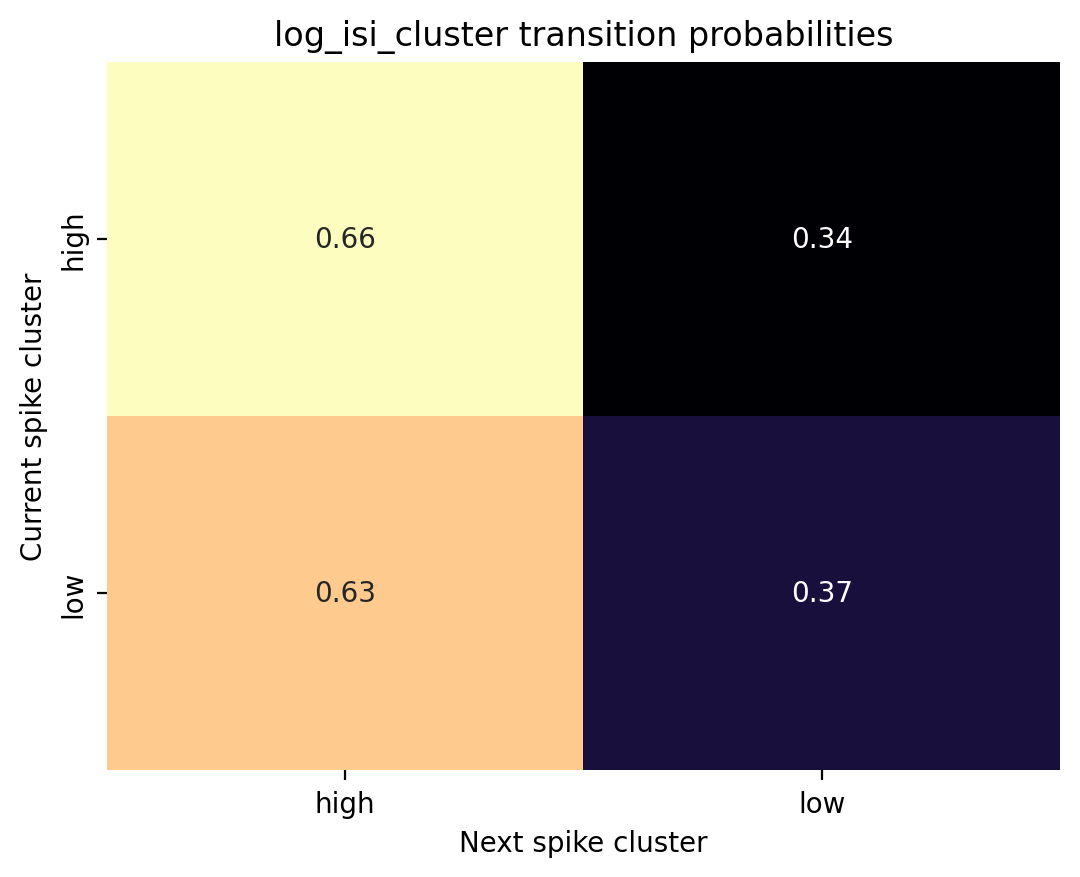


→ 4. Visualizing feature distributions by cluster


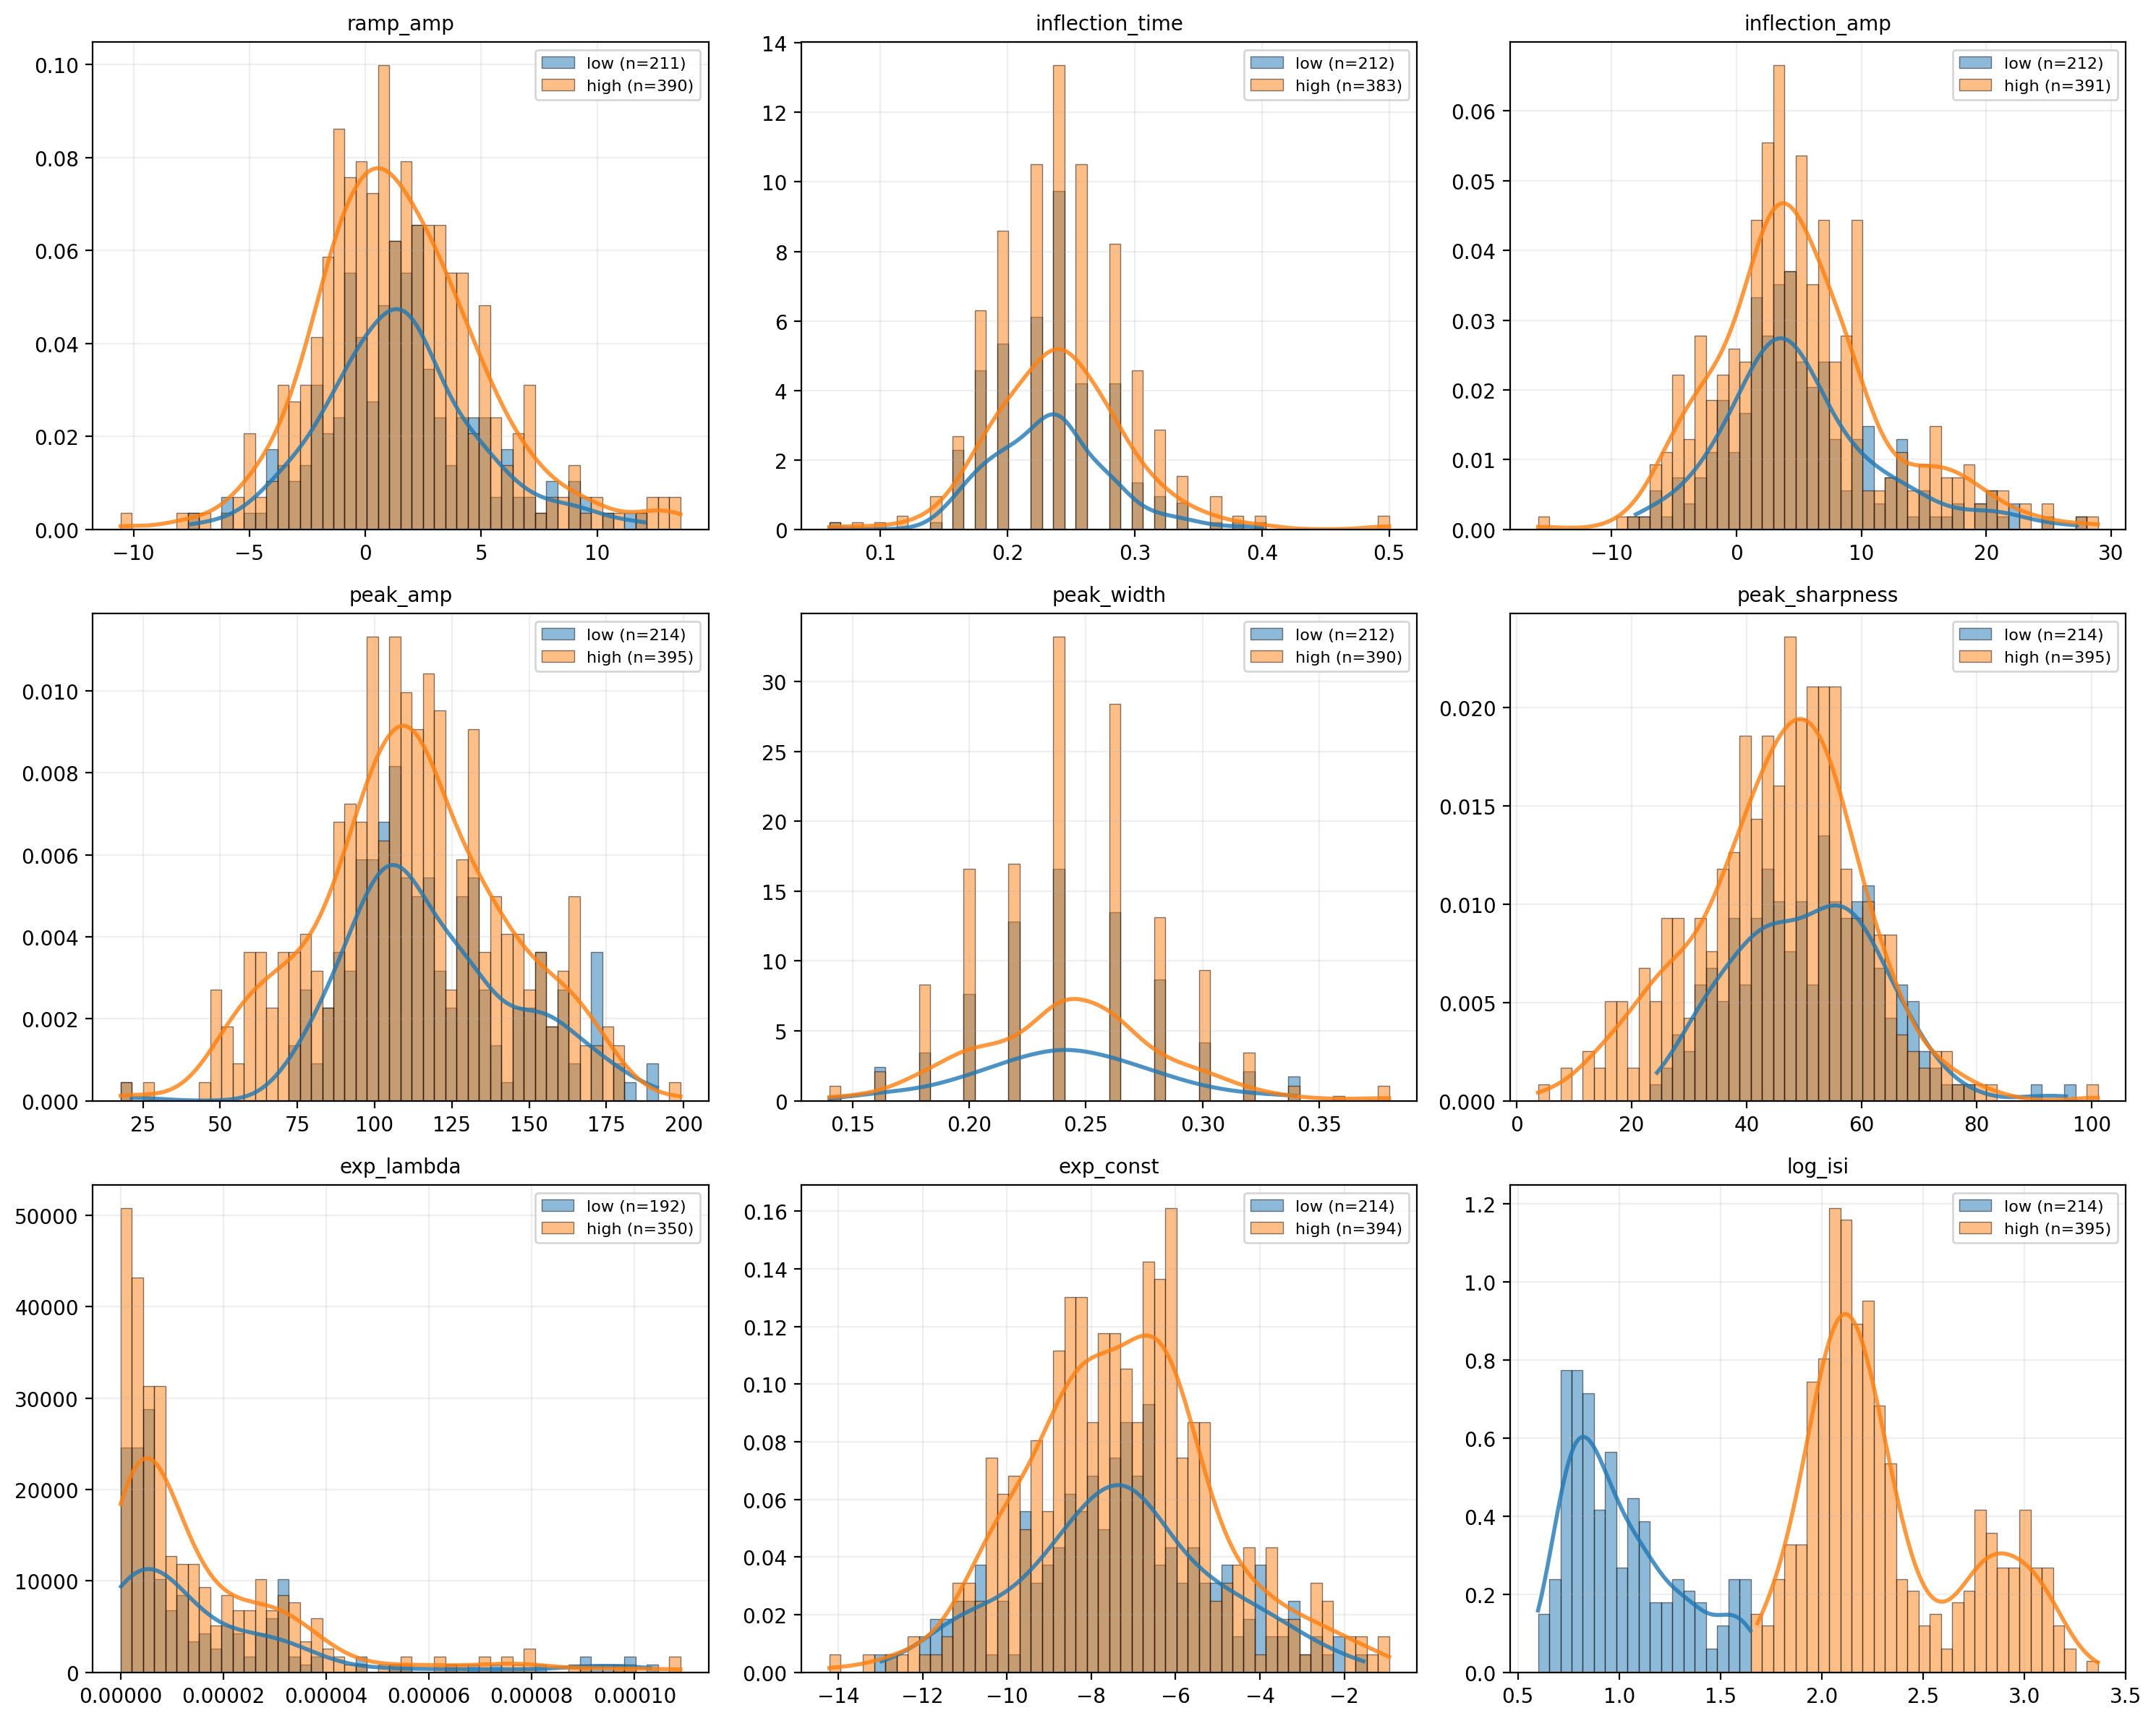


→ 5. Statistical analysis for: log_isi
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.760
Interpretation: Very Large


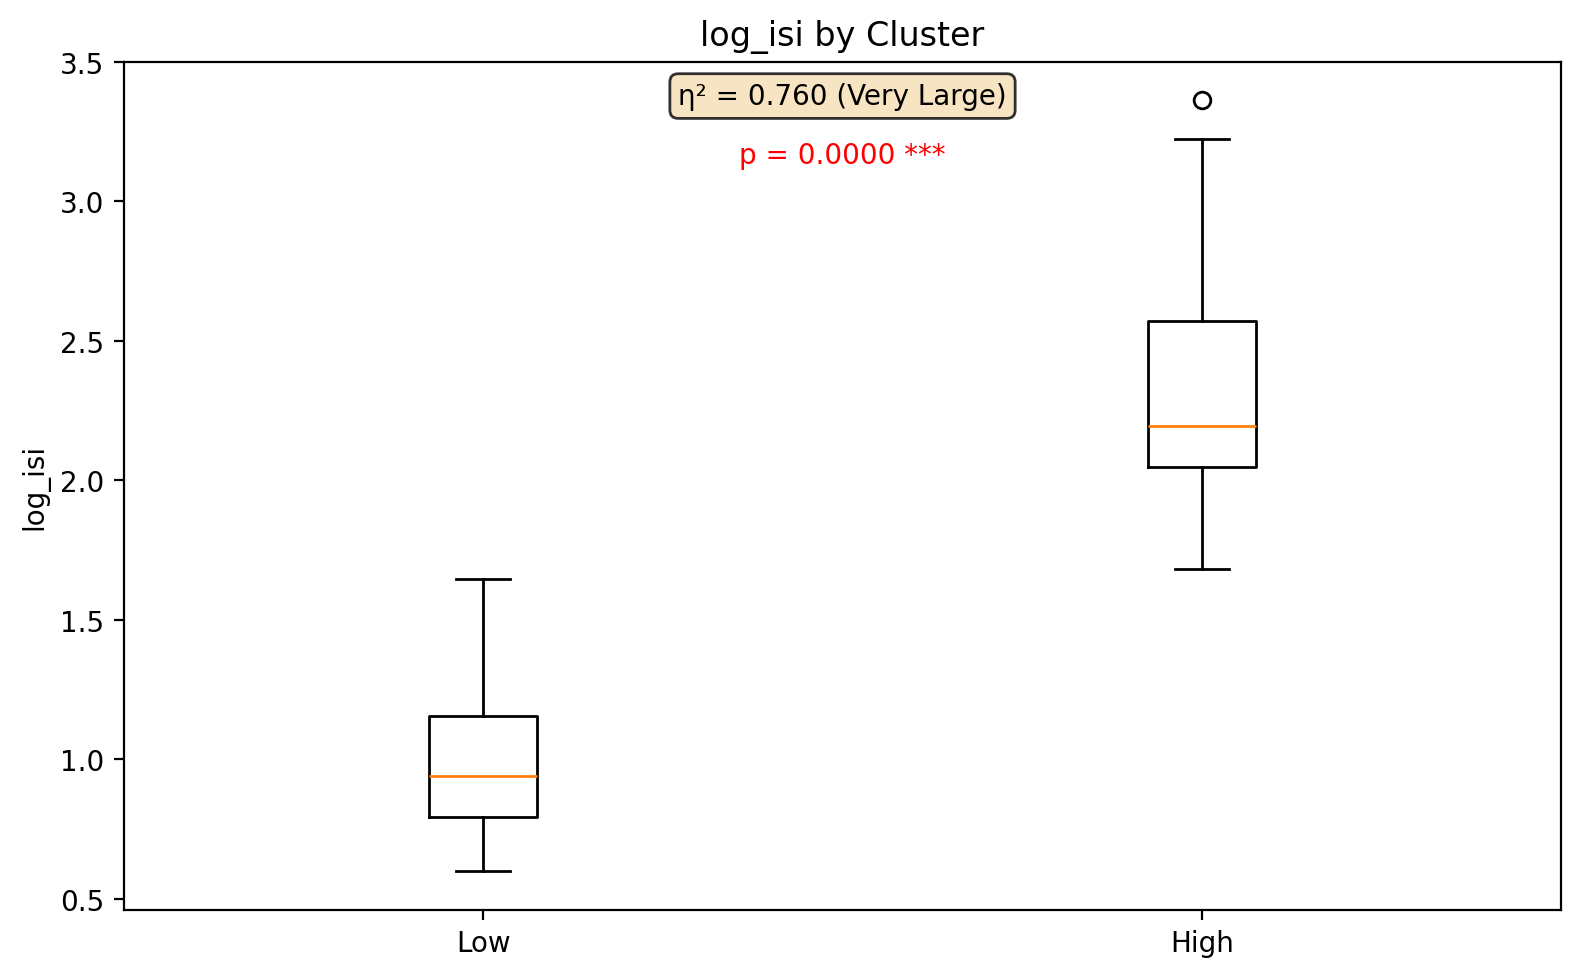


===== REPORT COMPLETE =====



In [19]:
all_reports = []

# Filter columns first to ensure the index is continuous
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # Pass 'i' as the cluster_group_id
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    all_reports.append(row_df)

# Final Master DataFrame
master_report_df = pd.concat(all_reports, ignore_index=True)

In [20]:
# Save cluster quality report for population-level comparison analysis
report_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_report.pkl')
with open(report_pickle, 'wb') as f:
    pickle.dump(master_report_df, f)


In [21]:
# Compute and save peak-aligned average waveforms for each cluster group.
# Saved to a lightweight pickle used by the population comparison notebook.
wf_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_waveforms.pkl')
if FORCE_CLUSTER or not os.path.exists(wf_pickle):
    cluster_cols = [c for c in df_features_clust.columns if c.endswith('_cluster')]
    wf_data = compute_cluster_waveforms(sp, df_features_clust, cluster_cols)
    with open(wf_pickle, 'wb') as f:
        pickle.dump(wf_data, f)
    print(f"  Saved: {os.path.basename(wf_pickle)}")
else:
    print(f"  [cache] {os.path.basename(wf_pickle)}")


  [cache] c37_cluster_waveforms.pkl
